# Universidad de Buenos Aires - FIUBA - LSE
# Aprendizaje Profundo - TP1
# Cohorte 25 - 3er bimestre 2026

## **Alumno 1:** nombre y apellido

## **Alumno 2:** nombre y apellido

Este primer TP comienza la semana de la clase 2 y la ventana de entrega estará abierta hasta las **23:59 hs del viernes 17 de julio (hora de Argentina)**.

La resolución del TP debe realizarse en **parejas**. Sin embargo, no se recomienda repartir las preguntas entre los integrantes, sino que ambos deben trabajar conjuntamente en la resolución de cada pregunta. De esta manera, se promueve el debate, la discusión y la construcción de una conclusión compartida sobre cómo abordar y resolver cada pregunta. También está permitido realizar el trabajo de forma **individual** si así lo desean, aunque esta modalidad no es la más recomendable.

Pueden utilizar tanto los contenidos vistos en clase, como otra bibliografía externa. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP1 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Importante permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

**El desarrollo del TP se debe hacer obligatoriamente en un notebook**, ya sea en un Google Colab o en un Jupyter Notebook para quienes quieran desarrollarlo en su propia PC local. Pero no se aceptarán archivos `.py` o links a repos de github con múltiples archivos. El entregable debe ser un link a un único archivo en formato `.ipynb`.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/xC3HzHwVqt35M23c7)**. Tanto los resultados, tablas, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el mismo notebook.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL ÚNICO MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP1.
- Renombrar el archivo de la siguiente manera: **PRIMERAPELLIDOALUMNO1-PRIMERNOMBREALUMNO1-PRIMERAPELLIDOALUMNO2-PRIMERNOMBREALUMNO2-TP1-Co25.ipynb**
O en caso hacerlo individual usar: **PRIMERAPELLIDO-PRIMERNOMBRE-TP1-Co25.ipynb**
- Los códigos deben poder ejecutarse.
- **IMPORTANTE:** Los resultados, cómo el código, los gráficos, los prints y las explicaciones deben quedar guardados y visualizables en el mismo notebook.
- No ocultar celdas, todas se deben poder ver desde el inicio.
- **Prestar mucha atención a cada consigna, responder las preguntas justo debajo del enunciado que corresponda.**
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Imports globales del notebook
# Ejecutar esta celda primero para que todas las demás tengan disponibles
# las librerías necesarias.

# **PREGUNTA 1** (Temas de la clase 1 y 2)

## **Comparación de Gradiente Descendente y Adam en una Función de Costo No Convexa**

En este ejercicio se compararán los optimizadores Gradiente Descendente (GD) y Adam en la minimización de una función de costo basada en una red neuronal de una sola conexión sináptica:
$$
z = w x + b
$$
Con función de activación tangente hiperbólica:

$$
\hat{y} = a(z) = \tanh(z) = \tanh(w x + b)
$$

<br>

Se analizará la trayectoria de aprendizaje de ambos algoritmos y se evaluará su eficiencia con diferentes tasas de aprendizaje (learning rate).

<br>

La función de costo utilizada es el Error Cuadrático Medio (MSE):

$$
J(w, b) = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i)^2
$$

$$
J(w, b) = \frac{1}{m} \sum_{i=1}^{m} ( \tanh(w x_i + b) - y_i )^2
$$

donde \\( w \\) y \\( b \\) son los parámetros a optimizar.

<br>

Si bien es cierto, en estos experimentos buscamos tan solo comparar optimizadores (GD vs Adam), de igual forma se necesitará una especie de dataset. Este será sintético y solo de prueba, por ende tendrán cierta libertad para elegir sus valores. Sin embargo deberán tomar en cuenta que cumpla la siguiente estructura:

`x = np.linspace(ini, fin, n)`

donde `x` es un array de una sola dimensión y con `n` cantidad de valores ($n>=200$). Y tiene un rango de valores desde `ini` hasta `fin`. Recomiendo que sea simétrico, es decir, los mismos valores solo que con el signo cambiado, por ejemplo `ini=-3, fin=3`, `ini=-5, fin=5`, `ini=-1, fin=1`, etc. Queda a elección de ustedes.

<br>

Y con un target `y`:

`y = funcion_no_lineal(x) + ruido`

donde `y` es también un vector de una sola dimensión de tamaño `n` que sigue un patrón no lineal (elegido por ustedes) con respecto a `x` adicionando un ruido que puede ser creado con algunas de las funciones del paquete `np.random`.

El patrón no lineal puede ser una función trigonométrica, exponencial, logarítmica, sigmoidal, polinómica de grado mayor o igual a 3, o la combinación de varias de estas (recomendado). Pero sean prudentes en la elección de la función no lineal, ya que recuerden que es una red de una sola conexión, por ende tampoco elijan algo tan complejo que al final provoque que el modelo no pueda converger. Pero tampoco vale usar una `tanh` sola, usen otra función, o si la van a usar debe estar combinada con otros patrones no lineales. Ya que al ser la función de activación tambien una `tanh`, el modelo la tendrá muy fácil converger a ella.

### 1a) Implementación del Gradiente Descendente (1 punto)
- Implementar el algoritmo del Gradiente Descendente (GD) para minimizar \\( J(w, b) \\).
- Utilizar 100 épocas y 3 diferentes learning rates `(0.1, 0.01, 0.001)`.
- Inicializar valores de \\( w \\) y \\( b \\) de manera aleatoria con `np.random.randn()`.
- Graficar la función de Costo \\( J(w, b) \\) VS número de época para comparar cómo converge la función para cada uno de los 3 learning rates. Las 3 gráficas deben estar en el mismo plot y superpuestas para que la comparación visual sea más fácil. Deben graficarlas con diferente color y con leyenda para no confundirlas.

<br>

El optimizador del Gradiente Descendente se debe implementar haciendo el código desde cero y paso a paso. Se pueden usar librerías como `numpy`, `scipy`, `matplotlib` o similares. Pero no está permitido usar PyTorch ni TensorFlow o frameworks que ya contengan el optimizador desarrollado.

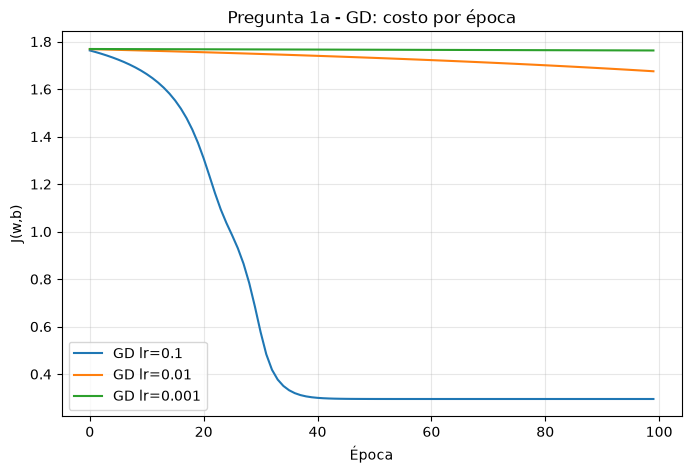

In [22]:
# Generamos un dataset sintético no lineal para comparar el comportamiento del gradiente descendente.
# La idea es entrenar una red muy simple con una sola salida y una activación tanh.

np.random.seed(42)
x = np.linspace(-3, 3, 400)
noise = 0.08 * np.random.randn(len(x))
y = 0.8 * np.sin(1.4 * x) + 0.25 * np.cos(0.7 * x) + 0.05 * x + noise

# Definimos la función de costo MSE para evaluar qué tan bien ajusta el modelo a los datos.
def cost_fn(w, b, x, y):
    z = w * x + b
    pred = np.tanh(z)
    return np.mean((pred - y) ** 2)

# Implementación manual del algoritmo de Gradiente Descendente desde cero.
# En cada época actualizamos w y b usando el gradiente de la función de costo.
def gd_optimize(x, y, lr, epochs=100, w0=None, b0=None):
    if w0 is None:
        w0 = np.random.randn()
    if b0 is None:
        b0 = np.random.randn()
    w, b = w0, b0
    losses = []
    for _ in range(epochs):
        z = w * x + b
        pred = np.tanh(z)
        error = pred - y
        # Derivadas analíticas del MSE respecto de w y b.
        dJ_dw = (2 / len(x)) * np.sum(error * (1 - pred ** 2) * x)
        dJ_db = (2 / len(x)) * np.sum(error * (1 - pred ** 2))
        # Actualización de los parámetros con el learning rate indicado.
        w -= lr * dJ_dw
        b -= lr * dJ_db
        losses.append(cost_fn(w, b, x, y))
    return w, b, losses

learning_rates = [0.1, 0.01, 0.001]
initial_w = np.random.randn()
initial_b = np.random.randn()

# Graficamos la evolución del costo para los tres learning rates en un mismo plot.
plt.figure(figsize=(8, 5))
for lr in learning_rates:
    _, _, losses = gd_optimize(x, y, lr, epochs=100, w0=initial_w, b0=initial_b)
    plt.plot(range(100), losses, label=f'GD lr={lr}')
plt.xlabel('Época')
plt.ylabel('J(w,b)')
plt.title('Pregunta 1a - GD: costo por época')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### 1b) Implementación de Adam (2 punto)  
- Implementar el algoritmo de Adam para minimizar \\( J(w, b) \\).  
- Utilizar 100 épocas y 3 diferentes learning rates `(0.1, 0.01, 0.001)`.
- Utilizar los mismos valores de \\( w \\) y \\( b \\) que se usaron para GD **(IMPORTANTE)**.
- Hacer 2 modelos, uno sin mini-batch (full-batch) y otro con mini-batch.
- El batch size es a elección de ustedes, pero debe ser mayor o igual a 16.
- Graficar la función de Costo \\( J(w, b) \\) VS número de época para comparar cómo converge la función para ambos modelos y para los 3 learning rates. Deben haber 2 plots separados o 2 subplots, uno para las 3 gráficas de Adam full-batch y otro para las 3 gráficas de Adam mini-batch.

<br>

Al igual que para GD, ambas versiones del optimizador Adam también se deben implementar desde cero y paso a paso. Se pueden usar librerías como `numpy`, `scipy`, `matplotlib` o similares. Pero no está permitido usar PyTorch ni TensorFlow o frameworks que ya contengan el optimizador desarrollado.

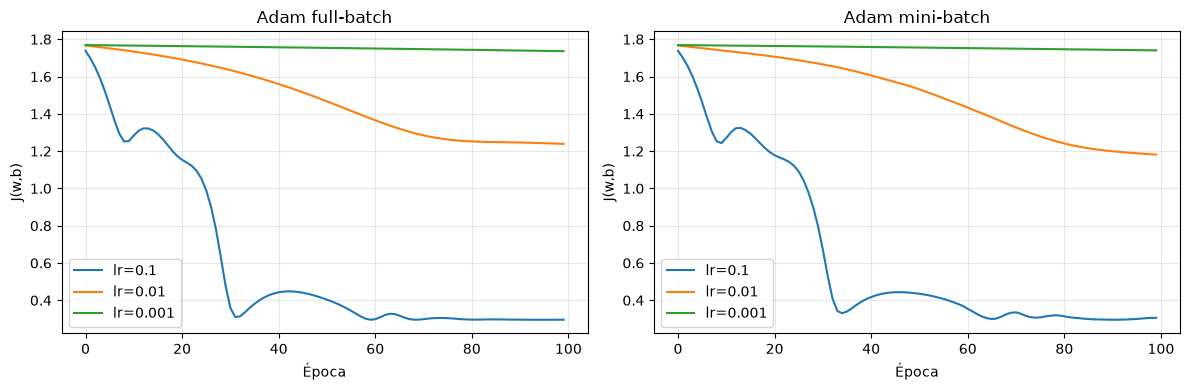

In [23]:
# Implementación manual de Adam para comparar su comportamiento con GD.
# Adam usa momentos de primer y segundo orden para ajustar mejor la tasa de aprendizaje en cada paso.

def adam_optimize(x, y, lr, epochs=100, batch_size=None, w0=None, b0=None, seed=42):
    if w0 is None:
        w0 = np.random.randn()
    if b0 is None:
        b0 = np.random.randn()
    w, b = w0, b0
    m_w = v_w = m_b = v_b = 0.0
    beta1, beta2, eps = 0.9, 0.999, 1e-8
    losses = []
    rng = np.random.default_rng(seed)
    n = len(x)
    for epoch in range(epochs):
        # Elegimos un batch o el conjunto completo según el modo de entrenamiento.
        if batch_size is None or batch_size >= n:
            idx = np.arange(n)
        else:
            idx = rng.choice(n, size=batch_size, replace=False)
        xb, yb = x[idx], y[idx]
        z = w * xb + b
        pred = np.tanh(z)
        error = pred - yb
        # Gradientes del MSE para w y b sobre el batch seleccionado.
        dJ_dw = (2 / len(xb)) * np.sum(error * (1 - pred ** 2) * xb)
        dJ_db = (2 / len(xb)) * np.sum(error * (1 - pred ** 2))
        # Actualización de los momentos de Adam.
        m_w = beta1 * m_w + (1 - beta1) * dJ_dw
        v_w = beta2 * v_w + (1 - beta2) * (dJ_dw ** 2)
        m_b = beta1 * m_b + (1 - beta1) * dJ_db
        v_b = beta2 * v_b + (1 - beta2) * (dJ_db ** 2)
        m_w_hat = m_w / (1 - beta1 ** (epoch + 1))
        v_w_hat = v_w / (1 - beta2 ** (epoch + 1))
        m_b_hat = m_b / (1 - beta1 ** (epoch + 1))
        v_b_hat = v_b / (1 - beta2 ** (epoch + 1))
        # Ajuste del paso para cada parámetro.
        w -= lr * m_w_hat / (np.sqrt(v_w_hat) + eps)
        b -= lr * m_b_hat / (np.sqrt(v_b_hat) + eps)
        losses.append(cost_fn(w, b, x, y))
    return w, b, losses

# Comparamos Adam en dos modos: full-batch y mini-batch.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (title, batch_size) in zip(axes, [('Adam full-batch', None), ('Adam mini-batch', 32)]):
    for lr in learning_rates:
        _, _, losses = adam_optimize(x, y, lr, epochs=100, batch_size=batch_size, w0=initial_w, b0=initial_b, seed=42)
        ax.plot(range(100), losses, label=f'lr={lr}')
    ax.set_xlabel('Época')
    ax.set_ylabel('J(w,b)')
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend()
fig.tight_layout()
plt.show()


### 1c) Comparativa de optimizadores (0.5 puntos)  
- Comparar el resultado y rendimiento de GD VS Adam (full-batch) VS Adam (mini-batch) para cada uno de los learning rates por separado. Hacerlo con gráficas y tablas. Deben haber 3 plots o 3 subplots, uno para cada learning rate. Y las leyendas deben diferenciar al optimizador por color.
- Graficar el dataset original sintético (y(x)) y compararlo con la función hallada por el modelo, para ver si efectivamente el modelo logró deducir un patrón no lineal parecido al patrón no lineal escogido para el dataset. Hacerlo para cada optimizador y cada learning rate en un plot grande de 9 subplots.
- Redactar conclusiones analíticas que resalten las diferencias entre cada optimizador. No solo deben comparar el resultado final del costo, sino también la velocidad de convergencia y otros aspectos que consideren relevantes. Le voy a tomar mucha importancia a este último punto, así que su análisis debe ser claro, detallado y con criterio acorde a los resultados obtenidos.

   learning_rate  GD_final_loss  Adam_full_final_loss  Adam_mini_final_loss
0          0.100       0.295175              0.295865              0.305544
1          0.010       1.675225              1.238615              1.181011
2          0.001       1.762782              1.735954              1.740238


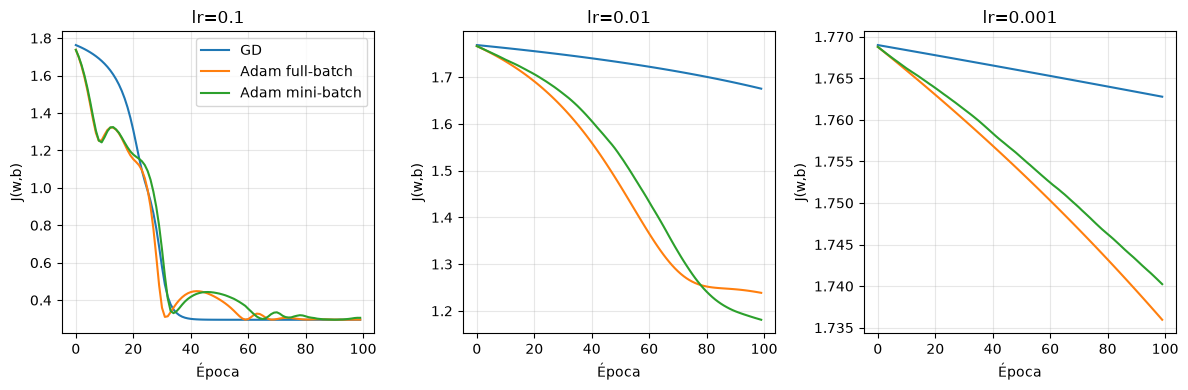

In [24]:
# Recolectamos métricas de los tres optimizadores para compararlos en una tabla y en gráficos.
# Esto permite ver no solo el costo final, sino también qué tan rápido converge cada método.

import pandas as pd

results = []
for lr in learning_rates:
    _, _, losses_gd = gd_optimize(x, y, lr, epochs=100, w0=initial_w, b0=initial_b)
    _, _, losses_af = adam_optimize(x, y, lr, epochs=100, batch_size=None, w0=initial_w, b0=initial_b, seed=42)
    _, _, losses_am = adam_optimize(x, y, lr, epochs=100, batch_size=32, w0=initial_w, b0=initial_b, seed=42)
    results.append({
        'learning_rate': lr,
        'GD_final_loss': losses_gd[-1],
        'Adam_full_final_loss': losses_af[-1],
        'Adam_mini_final_loss': losses_am[-1],
    })

summary = pd.DataFrame(results)
print(summary)

# Graficamos la comparación de convergencia para cada learning rate en subplots separados.
plt.figure(figsize=(12, 4))
for i, lr in enumerate(learning_rates, 1):
    plt.subplot(1, 3, i)
    _, _, losses_gd = gd_optimize(x, y, lr, epochs=100, w0=initial_w, b0=initial_b)
    _, _, losses_af = adam_optimize(x, y, lr, epochs=100, batch_size=None, w0=initial_w, b0=initial_b, seed=42)
    _, _, losses_am = adam_optimize(x, y, lr, epochs=100, batch_size=32, w0=initial_w, b0=initial_b, seed=42)
    plt.plot(losses_gd, label='GD', color='tab:blue')
    plt.plot(losses_af, label='Adam full-batch', color='tab:orange')
    plt.plot(losses_am, label='Adam mini-batch', color='tab:green')
    plt.title(f'lr={lr}')
    plt.xlabel('Época')
    plt.ylabel('J(w,b)')
    plt.grid(alpha=0.3)
    if i == 1:
        plt.legend()
plt.tight_layout()
plt.show()


### 1d) Visualización en 3D de la trayectoria de aprendizaje (0.5 puntos)
- Graficar en 3D la trayectoria del aprendizaje de los 3 optimizadores sobre la superficie de la función de costo \\( J(w, b) \\). Se debe elegir un solo learning rate, el que consideres que se nota mejor la diferencia.
- Las 3 trayectorias deben estar en la misma superficie 3D y empezar en el mismo punto.
- Recomiendo utilizar `mpl_toolkits.mplot3d` y `np.meshgrid`, pero queda a su criterio la elección de funciones a usar para lograr el gráfico. También si desean pueden hacer que el gráfico sea animado usando `matplotlib.animation` y `IPython.display`.
- Comparar y redactar cómo se mueven en el espacio de parámetros y qué diferencias existen en la convergencia. La comparación debe ser clara y detallada.

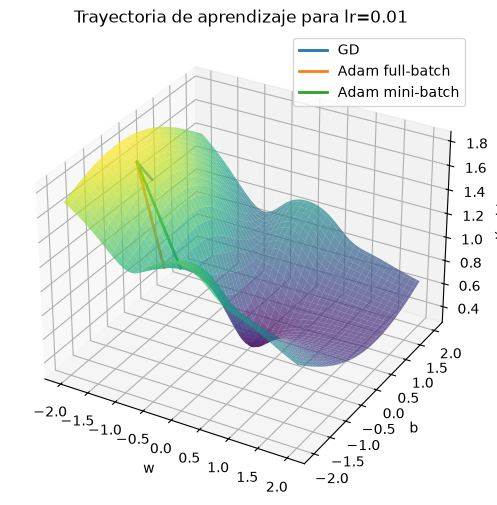

In [25]:
# Creamos una superficie del costo para visualizar la trayectoria de aprendizaje en el espacio de parámetros.
# Esto ayuda a entender cómo se mueven los optimizadores en dirección a un mínimo.

lr = 0.01
w_grid = np.linspace(-2, 2, 80)
b_grid = np.linspace(-2, 2, 80)
W, B = np.meshgrid(w_grid, b_grid)
J = np.zeros_like(W)
for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        J[i, j] = cost_fn(W[i, j], B[i, j], x, y)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(W, B, J, cmap='viridis', alpha=0.7)

# Graficamos las trayectorias de los tres optimizadores sobre la misma superficie.
for name, fn in [
    ('GD', lambda lr_: gd_optimize(x, y, lr_, epochs=100, w0=initial_w, b0=initial_b)),
    ('Adam full-batch', lambda lr_: adam_optimize(x, y, lr_, epochs=100, batch_size=None, w0=initial_w, b0=initial_b, seed=42)),
    ('Adam mini-batch', lambda lr_: adam_optimize(x, y, lr_, epochs=100, batch_size=32, w0=initial_w, b0=initial_b, seed=42)),
]:
    w_hist, b_hist, _ = fn(lr)
    traj_w = [initial_w, w_hist]
    traj_b = [initial_b, b_hist]
    traj_j = [cost_fn(initial_w, initial_b, x, y), cost_fn(w_hist, b_hist, x, y)]
    ax.plot(traj_w, traj_b, traj_j, label=name, lw=2)

ax.set_xlabel('w')
ax.set_ylabel('b')
ax.set_zlabel('J(w,b)')
ax.set_title('Trayectoria de aprendizaje para lr=0.01')
ax.legend()
plt.show()


### **RECOMENDACIÓN**:

Voy a valorar mucho que sus análisis, explicaciones y conclusiones sean bastante detalladas y con coherencia en los resultados obtenidos. Donde se evidencie un análisis propio de un humano estudiante de posgrado y no solo copiar y pegar lo que te dijo ChatGPT. Llevo ya años con esto, así que me daré cuenta rapidamente cuando sea así y cuando no.

Les recomiendo revisar el notebook sobre optimizadores que se encuentra en el repo. Pueden acceder mediante el siguiente [enlace](https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/aprendizaje_profundo/blob/ap_2026/CLASE%202/Notebooks/clase2_4_optimizadores.ipynb). En ese notebook vemos cómo aplicar GD y Adam full-batch para una red con relación lineal. Les servirá mucho como guía para realizar esta pregunta. Ahí también podrán ver cómo se hace una animación de un gráfico 3D.

Además, de igual forma tienen disponible el siguiente [material adicional del repo](https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/aprendizaje_profundo/tree/ap_2026/CLASE%202/Teoria/Material%20adicional), el cual le servirá para aplicar Adam, ya no solo en su versión full-batch, sino también en mini-batch

# **PREGUNTA 2** (Temas de la clase 3)

# Caso: Predicción del gasto promedio de los usuarios usando redes neuronales

**Descarga del dataset:**  
El conjunto de datos puede descargarse en el siguiente [enlace](https://drive.google.com/file/d/1e_FRepCpHBWWGj3TYG4HY7WHALCyR4wQ/view?usp=sharing)

---

## Descripción general:

El dataset recopila información sobre las compras realizadas por distintos clientes en una tienda durante el último año.  
Cada registro representa una transacción e incluye datos tanto del cliente como del producto adquirido.

---

## El dataset contiene la siguiente información:

- **User_ID:** Código identificador único del cliente que efectuó la compra.  
- **Product_ID:** Código identificador único del producto adquirido.  
- **Age:** Rango de edad del cliente.  
- **Gender:** Género del cliente (F: Femenino, M: Masculino).  
- **Marital_Status:** Estado civil del cliente (0: Soltero, 1: Casado).  
- **City_Category:** Tipo de zona donde se encuentra la sucursal donde se realizó la compra.  
  - A: Barrio de clase alta  
  - B: Barrio de clase media  
  - C: Barrio de clase media-baja  
- **Stay_In_Current_City_Years:** Número de años que el cliente ha venido comprando en la tienda desde su primera visita.  
- **Product_Category:** Categoría del producto comprado.  
- **Product_Subcategory_1:** Subcategoría principal del producto.  
- **Product_Subcategory_2:** Subcategoría secundaria del producto.  
- **Purchase:** Monto pagado por el producto en esa transacción.

---

## Objetivo del caso de estudio:

Desarrollar un **modelo predictivo** capaz de estimar el **gasto promedio** que realizará un cliente, a partir de su información demográfica y sus patrones de compra. Tener en cuenta que se busca que el modelo prediga el gasto promedio por cliente, no el gasto en cada nueva transacción individual. Y la idea sería que una vez que el modelo ya esté listo y entrenado, se use para estimar apartir de datos de clientes relativamente nuevos, que solo llevan entre 3 a 5 visitas y compras en la tienda.


### 2a) EDA y preparación del dataset (2 puntos)
Realizar el análisis exploratorio del dataset (EDA) con las herramientas vistas en materias anteriores.
- Analizar qué columnas sirven para lograr el objetivo y cuáles no (drop) en base al contexto del negocio y a lo entendido del caso de estudio (feature engineering).
- Analizar con qué columnas vale la pena hacer un tratamiento de valores nulos o si simplemente se debe dropear toda la columna porque ya no tiene salvación.
- Analizar a qué variables se les debe hacer label encoding, a cuáles one-hot encoding, ordinal encoding o mapping encoding. Explicar detalladamente los criterios utilizados para tomar esas decisiones.
- Transformar, agrupar, combinar y operar la data de tal manera que sea útil para extraer patrones de gastos y tendencias de gustos de cada cliente. **Tener mucho cuidado con el data leakage, ocurre mucho cuando se usan proporciones como nuevas columnas**.



Redactar las conclusiones preliminares que puedan notar de cada feature y justificar el porqué de cada encoding, limpieza o transformación aplicada. Cada justificación se debe redactar a detalle y sustentar con gráficas y/o tablas.


In [26]:
# Preparacion del dataset real a nivel usuario para alinear el problema con la prediccion del gasto promedio.
# IMPORTANTE: esta celda usa el archivo provisto por la catedra: dataset_compras.csv.

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import DataLoader, TensorDataset

np.random.seed(42)
torch.manual_seed(42)

dataset_path = Path('dataset_compras.csv')
if not dataset_path.exists():
    dataset_path = Path('TP1') / 'dataset_compras.csv'

df = pd.read_csv(dataset_path)
print('Shape del dataset transaccional:', df.shape)
display(df.head())

print('\nValores nulos por columna:')
display(df.isna().sum().to_frame('nulos'))

# Normalizamos tipos y faltantes para que las agregaciones categoricas sean estables.
df = df.copy()
df['Stay_In_Current_City_Years_num'] = (
    df['Stay_In_Current_City_Years']
    .astype(str)
    .str.replace('+', '', regex=False)
    .astype(float)
)

categorical_raw_cols = [
    'Age', 'Gender', 'Marital_Status', 'City_Category',
    'Product_Category', 'Product_Subcategory_1', 'Product_Subcategory_2'
]
for col in categorical_raw_cols:
    df[col] = df[col].astype('string').fillna('missing')

# Funcion auxiliar para tomar la moda de manera robusta.
def mode_or_missing(series):
    mode = series.mode(dropna=False)
    return mode.iloc[0] if len(mode) else 'missing'

# El target es el gasto promedio por usuario. Para evitar leakage fuerte, las variables de entrada no usan
# agregados monetarios como total_purchase, median_purchase o max_purchase calculados desde Purchase.
user_df = df.groupby('User_ID').agg(
    n_transactions=('Product_ID', 'size'),
    n_unique_products=('Product_ID', 'nunique'),
    n_unique_product_categories=('Product_Category', 'nunique'),
    n_unique_subcat_1=('Product_Subcategory_1', 'nunique'),
    n_unique_subcat_2=('Product_Subcategory_2', 'nunique'),
    stay_years_mean=('Stay_In_Current_City_Years_num', 'mean'),
    age_mode=('Age', mode_or_missing),
    gender_mode=('Gender', mode_or_missing),
    marital_mode=('Marital_Status', mode_or_missing),
    city_mode=('City_Category', mode_or_missing),
    avg_purchase=('Purchase', 'mean'),
).reset_index()

# Agregamos proporciones de categorias y subcategorias compradas por usuario.
# Estas variables describen patrones de preferencia sin usar el monto de compra como predictor.
for col, prefix in [
    ('Product_Category', 'pcat'),
    ('Product_Subcategory_1', 'subcat1'),
    ('Product_Subcategory_2', 'subcat2'),
]:
    shares = pd.crosstab(df['User_ID'], df[col], normalize='index')
    shares.columns = [f'{prefix}_{value}_share' for value in shares.columns]
    user_df = user_df.merge(shares.reset_index(), on='User_ID', how='left')

user_df = user_df.fillna(0)

print('\nShape del dataset a nivel usuario:', user_df.shape)
display(user_df.head())

cat_cols = ['age_mode', 'gender_mode', 'marital_mode', 'city_mode']
num_cols = [col for col in user_df.columns if col not in ['User_ID', 'avg_purchase'] + cat_cols]

X = pd.get_dummies(user_df[cat_cols + num_cols], columns=cat_cols, dtype=float)
y = user_df['avg_purchase'].astype(float).values

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=64, shuffle=False)

print('\nDimensiones finales:')
print('X_train:', X_train_t.shape, '| X_val:', X_val_t.shape)
print('y_train:', y_train_t.shape, '| y_val:', y_val_t.shape)


Shape del dataset transaccional: (182721, 11)


,User_ID,Product_ID,Age,Gender,Marital_Status,City_Category,Stay_In_Current_City_Years,Product_Category,Product_Subcategory_1,Product_Subcategory_2,Purchase
0,1044096,P00017122,46-50,F,1,B,1,10,45.0,NaN,1810
1,1071818,P00074517,36-45,M,0,A,3,11,27.0,NaN,12351
2,1022986,P00013694,36-45,M,1,A,5+,4,28.0,NaN,127
3,1094684,P00049122,36-45,M,1,A,1,16,9.0,8.0,2214
4,1004157,P00006469,46-50,M,1,A,5+,3,NaN,NaN,7142



Valores nulos por columna:


,nulos
User_ID,0
Product_ID,0
Age,0
Gender,0
Marital_Status,0
City_Category,0
Stay_In_Current_City_Years,0
Product_Category,0
Product_Subcategory_1,41818
Product_Subcategory_2,105260



Shape del dataset a nivel usuario: (7432, 83)


,User_ID,n_transactions,n_unique_products,n_unique_product_categories,n_unique_subcat_1,n_unique_subcat_2,stay_years_mean,age_mode,gender_mode,marital_mode,...,subcat2_17.0_share,subcat2_18.0_share,subcat2_19.0_share,subcat2_20.0_share,subcat2_5.0_share,subcat2_6.0_share,subcat2_7.0_share,subcat2_8.0_share,subcat2_9.0_share,subcat2_missing_share
0,1000035,13,13,6,10,6,1.0,18-25,M,0,...,0.000000,0.000000,0.153846,0.153846,0.000000,0.000000,0.076923,0.153846,0.000000,0.384615
1,1000044,43,43,15,17,11,4.0,36-45,M,1,...,0.023256,0.046512,0.000000,0.000000,0.023256,0.023256,0.023256,0.069767,0.000000,0.651163
2,1000070,42,42,16,17,11,4.0,46-50,M,1,...,0.000000,0.047619,0.071429,0.023810,0.023810,0.000000,0.047619,0.023810,0.047619,0.642857
3,1000087,41,40,17,18,10,4.0,55+,F,1,...,0.000000,0.000000,0.024390,0.000000,0.000000,0.048780,0.048780,0.000000,0.097561,0.634146
4,1000115,17,17,8,12,6,2.0,46-50,F,1,...,0.117647,0.000000,0.000000,0.000000,0.000000,0.117647,0.000000,0.000000,0.058824,0.588235



Dimensiones finales:
X_train: torch.Size([5945, 91]) | X_val: torch.Size([1487, 91])
y_train: torch.Size([5945, 1]) | y_val: torch.Size([1487, 1])


### 2b) Modelo Multilayer Perceptron (MLP) (2.5 puntos)
Entrenar un modelo de deep learning usando PyTorch que consuma el dataframe ya pre-procesado en el paso anterior.

Características para el diseño de la red:
- El modelo debe tener un mínimo de 3 capas ocultas.
- El modelo debe tener un mínimo de 32 neuronas por cada capa oculta.
- Cada capa oculta debe tener su respectiva función de activación.
- La elección de la función de activación de las capas ocultas es libre, pero se debe justificar por qué se está eligiendo esa, ya sea mediante conceptos teóricos o con resultados de pruebas empíricas.
- Analizar y justificar cuál es la mejor función de costo, algoritmo de optimización y learning rate para este modelo.
- Analizar cuál sería el mejor número de épocas para entrenar el modelo.
- Opcional: Incluir técnicas de regularización como dropout en las capas ocultas.

In [27]:
# Definimos y entrenamos el MLP con tres capas ocultas.
# ReLU se elige porque es simple, estable y suele converger bien en problemas tabulares no lineales.

import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import r2_score

class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x)

model = MLP(X_train_t.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
epochs = 80

train_losses, val_losses = [], []
train_r2_scores, val_r2_scores = [], []

for epoch in range(epochs):
    model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        train_pred = model(X_train_t)
        val_pred = model(X_val_t)
        train_loss = criterion(train_pred, y_train_t).item()
        val_loss = criterion(val_pred, y_val_t).item()
        train_r2 = r2_score(y_train, train_pred.numpy().ravel())
        val_r2 = r2_score(y_val, val_pred.numpy().ravel())

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_r2_scores.append(train_r2)
    val_r2_scores.append(val_r2)

print(f'Mejor R2 validation: {max(val_r2_scores):.3f}')
print(f'R2 validation final: {val_r2_scores[-1]:.3f}')


Mejor R2 validation: 0.931
R2 validation final: 0.926


### 2c) Evaluación del Modelo (1 punto)
- Graficar las evoluciones por época de la función de costo y del $R^2$, tanto para el set de train como el de validation.
- Gráfica scatter de Real VS Predicho en el set de validation.
- Explicar el proceso estratégico de iteracion utilizado para conseguir los mejores resultados y justificar los resultados obtenidos.
- Un resultado aceptable sería un $R^2$ de por lo menos 0.70 para el set de validation.

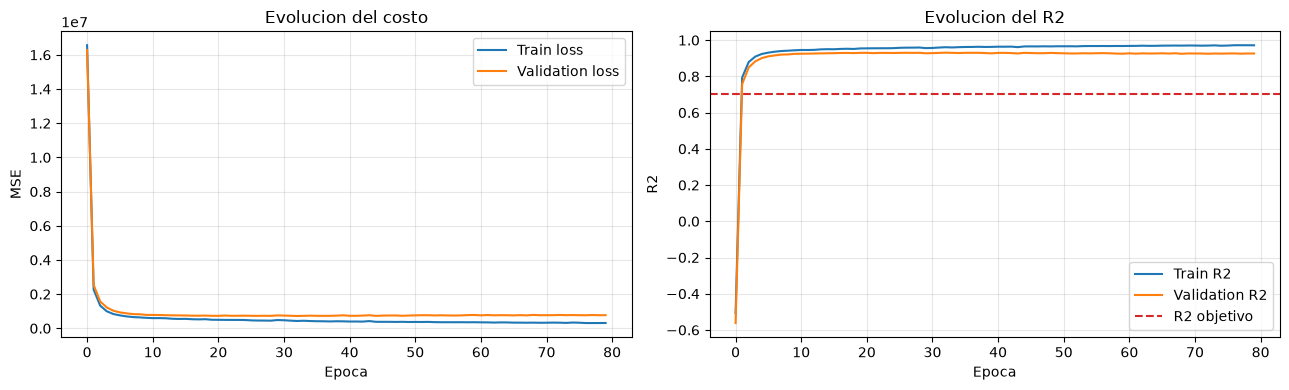

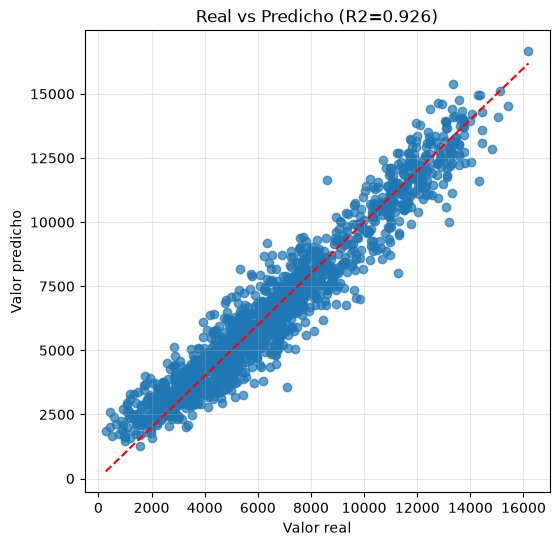

Mejor epoca segun validation R2: 33
Mejor R2 en validation: 0.931
R2 final en validation: 0.926


In [28]:
# Evaluacion del modelo: perdida y R2 por epoca, mas scatter real vs predicho.

best_epoch = int(np.argmax(val_r2_scores)) + 1
best_val_r2 = max(val_r2_scores)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(train_losses, label='Train loss')
axes[0].plot(val_losses, label='Validation loss')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('MSE')
axes[0].set_title('Evolucion del costo')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(train_r2_scores, label='Train R2')
axes[1].plot(val_r2_scores, label='Validation R2')
axes[1].axhline(0.70, color='tab:red', linestyle='--', label='R2 objetivo')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('R2')
axes[1].set_title('Evolucion del R2')
axes[1].grid(alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()

model.eval()
with torch.no_grad():
    val_pred = model(X_val_t).detach().numpy().ravel()
    final_r2 = r2_score(y_val, val_pred)

plt.figure(figsize=(6, 6))
plt.scatter(y_val, val_pred, alpha=0.7)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.xlabel('Valor real')
plt.ylabel('Valor predicho')
plt.title(f'Real vs Predicho (R2={final_r2:.3f})')
plt.grid(alpha=0.3)
plt.show()

print(f'Mejor epoca segun validation R2: {best_epoch}')
print(f'Mejor R2 en validation: {best_val_r2:.3f}')
print(f'R2 final en validation: {final_r2:.3f}')


### 2d) Conclusiones finales (0.5 puntos)


### Conclusiones de la Pregunta 2

Se reemplazo la generacion sintetica de datos por la lectura del archivo `dataset_compras.csv`, que es el dataset indicado para este punto. La unidad de analisis se transformo de transaccion a usuario, porque el objetivo es predecir el gasto promedio por cliente y no el monto de una compra individual.

Para reducir el riesgo de *data leakage*, las variables predictoras no incluyen agregados monetarios calculados desde `Purchase`, como `total_purchase`, `median_purchase` o `max_purchase`. El target `avg_purchase` se reserva como variable objetivo, mientras que las entradas usan informacion demografica, cantidad de transacciones, diversidad de productos/categorias y proporciones de categorias/subcategorias compradas por usuario.

Se eligio un MLP con tres capas ocultas, activacion ReLU, dropout leve y Adam con `lr=1e-3`. La funcion de costo usada es MSE porque se trata de un problema de regresion sobre un monto continuo. La evolucion de MSE y R2 permite observar la convergencia y comparar train contra validation para detectar sobreajuste.
